# Walmart Store Sales Forecasting — TimesFM (bonus)


In [1]:

%pip install -q seaborn "timesfm[torch]==2.0.1" mlflow dagshub



Note: you may need to restart the kernel to use updated packages.


In [2]:
!wget -q https://raw.githubusercontent.com/romaxod/ML-FINAL/main/preprocessing.py \
        https://raw.githubusercontent.com/romaxod/ML-FINAL/main/evaluation.py

In [3]:
import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)

CODE_PATHS = ["preprocessing.py", "evaluation.py"]

ARCH = "TimesFM"


In [4]:
import dagshub

DAGSHUB_USER = "rkvit23"
DAGSHUB_REPO = "ML-FINAL"

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow")

EXPERIMENT_NAME = f"{ARCH}_Training"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)


Accessing as rkvit23

Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

MLflow experiment: TimesFM_Training


In [5]:
!ls /kaggle/input/competitions/
prep.CANDIDATE_DIRS.append("/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/")



walmart-recruiting-store-sales-forecasting


In [6]:
train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()      # 39 weeks

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)


train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


In [7]:
features_clean = prep.clean_features(features_raw)

with mlflow.start_run(run_name=f"{ARCH}_Cleaning"):
    mlflow.log_params({
        "markdown_nan": "fill 0 + MarkDown_missing flag",
        "cpi_unemployment_nan": "per-store ffill/bfill",
        "negative_sales": "kept (returns are real signal)",
        "merge": "train/test LEFT JOIN stores, features",
    })
    mlflow.log_metrics({
        "n_rows_train": len(train_raw),
        "n_rows_test": len(test_raw),
        "n_series": train_raw.groupby(["Store", "Dept"]).ngroups,
        "n_negative_sales": int((train_raw.Weekly_Sales < 0).sum()),
        "pct_markdown_missing": float(features_raw[MD_COLS].isna().all(axis=1).mean()),
    })
print("cleaning done")


🏃 View run TimesFM_Cleaning at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6/runs/c5814808c7da42b7829f2dab924442b6
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6
cleaning done


In [8]:
# Series matrix on the full weekly grid (same preprocessing as the DL notebooks)
dm = prep.build_series_matrix(train_raw, HORIZON)
Y, series_idx = dm.Y, dm.series_idx
S, T = dm.n_series, dm.T
VAL_CUT, val_dates = dm.val_cut, dm.val_dates
val_actual = train_raw[train_raw.Date >= val_dates[0]][
    ["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]].copy()
print("series matrix:", Y.shape)


series matrix: (3331, 143)


## Loading the model

In [9]:
import torch
import timesfm

# timesfm>=2.0 API (TimesFM 2.5 checkpoint); the old TimesFm/TimesFmHparams API
# only installs on Python<=3.11, which Kaggle/Colab no longer ship by default.
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")
tfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=HORIZON,
        normalize_inputs=True,
        infer_is_positive=True,
    )
)
print("TimesFM loaded")


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

TimesFM loaded


## Zero-shot evaluation on validation

zero-shot forecast for 3331 series: 211s
🏃 View run TimesFM_ZeroShot_Val at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6/runs/3dd73390b5d249b9bde38176c6a358b1
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6
TimesFM zero-shot val WMAE = 1,672.1


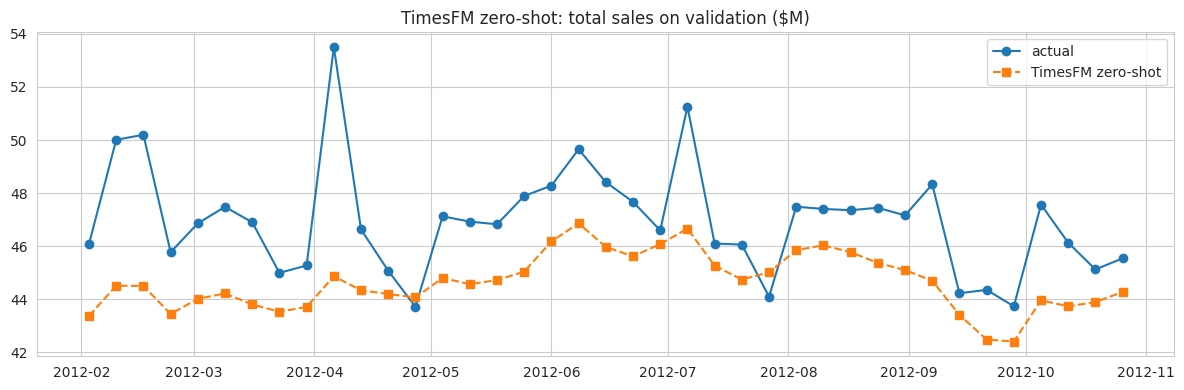

In [10]:
# context = first 104 weeks, forecast = last 39 weeks; freq=0 = weekly series.
t0 = time.time()
contexts = [Y[i, :VAL_CUT] for i in range(S)]
fc, _ = tfm.forecast(horizon=HORIZON, inputs=contexts)
fc = np.asarray(fc)[:, :HORIZON].clip(min=0)
print(f"zero-shot forecast for {S} series: {time.time()-t0:.0f}s")

dfp = pd.DataFrame(fc, index=series_idx, columns=val_dates)
dfp.columns.name = "Date"
long = dfp.stack().rename("pred").reset_index()
m = val_actual.merge(long, on=["Store", "Dept", "Date"], how="left")
m["pred"] = m["pred"].fillna(0)
val_score = wmae(m.Weekly_Sales, m.pred, m.IsHoliday)

with mlflow.start_run(run_name=f"{ARCH}_ZeroShot_Val"):
    mlflow.log_params({"checkpoint": "timesfm-2.5-200m-pytorch", "mode": "zero-shot",
                       "context_len": VAL_CUT, "horizon": HORIZON})
    mlflow.log_metric("val_wmae", val_score)
print(f"TimesFM zero-shot val WMAE = {val_score:,.1f}")

fig, ax = plt.subplots(figsize=(12, 4))
a = m.groupby("Date").Weekly_Sales.sum() / 1e6
p = m.groupby("Date").pred.sum() / 1e6
ax.plot(a.index, a.values, "o-", label="actual")
ax.plot(p.index, p.values, "s--", label="TimesFM zero-shot")
ax.set_title("TimesFM zero-shot: total sales on validation ($M)"); ax.legend()
plt.tight_layout(); plt.savefig("pictures/timesfm_val_total.png", dpi=120); plt.show()


## Pipeline + submission

In [11]:
REGISTER_AS_BEST = False   


contexts_full = [Y[i, :] for i in range(S)]
fc_test, _ = tfm.forecast(horizon=HORIZON, inputs=contexts_full)
fc_test = np.asarray(fc_test)[:, :HORIZON].clip(min=0)

fb_table, GLOBAL_MEAN = prep.make_fallback_table(train_raw)


class ForecastLookupPipeline(mlflow.pyfunc.PythonModel):
    """Foundation-model pipeline: stores the precomputed 39-week forecast for
    every series + a fallback table; predict() runs directly on raw test rows
    (loading it back does not require timesfm)."""

    def __init__(self, fc, series_index, train_end, horizon, fallback, global_mean):
        self.fc = fc
        self.pos = {sd: i for i, sd in enumerate(series_index)}
        self.train_end = train_end
        self.horizon = horizon
        self.fallback = fallback
        self.global_mean = global_mean

    def predict(self, context, model_input):
        df = model_input.copy()
        df["Date"] = pd.to_datetime(df["Date"])
        k = (((df.Date - self.train_end).dt.days // 7) - 1).clip(0, self.horizon - 1)
        k = k.astype(int).values
        idx = np.array([self.pos.get((s, d), -1) for s, d in zip(df.Store, df.Dept)])
        woy = df.Date.dt.isocalendar().week.astype(int)
        fb = (pd.DataFrame({"Dept": df.Dept.values, "WeekOfYear": woy.values})
              .merge(self.fallback, on=["Dept", "WeekOfYear"], how="left")
              ["Dept_WOY_Med"].fillna(self.global_mean).values)
        return np.where(idx >= 0, self.fc[idx.clip(min=0), k], fb)


wrapper = ForecastLookupPipeline(fc_test, list(series_idx), TRAIN_END, HORIZON,
                                 fb_table, GLOBAL_MEAN)
test_pred = wrapper.predict(None, test_raw[["Store", "Dept", "Date"]])

with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({"checkpoint": "timesfm-2.5-200m-pytorch", "mode": "zero-shot"})
    mlflow.log_metric("val_wmae", val_score)
    if os.path.exists("pictures/timesfm_val_total.png"):
        mlflow.log_artifact("pictures/timesfm_val_total.png")
    mlflow.pyfunc.log_model(
        "model", python_model=wrapper, code_paths=CODE_PATHS,
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)

sub = ev.make_submission(test_raw, test_pred, "submission_TimesFM.csv")
print("saved: submission_TimesFM.csv")


/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/07/10 10:20:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 10:20:23 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run TimesFM_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6/runs/ce0d42ccc62e4eba8742eb80b91ce7fb
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6
saved: submission_TimesFM.csv
